<a href="https://colab.research.google.com/github/Marell1000/DataScienceEcosystem/blob/main/Serapiao_S%26P500project_04_28.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**S&P 500 and The Volume Trap**

**Marell Serapiao**



In this assignment, you will create a notebook that uses data from the ISLP module and web-scraped data from Wikipedia. The goal is to extract real-world data, process it, and present it in a user-friendly format.

## Part 1: Selecting a Dataset

ISLP is the Python companion to *An Introduction to Statistical Learning*. It includes several pedagogically curated datasets across domains (marketing, finance, health, etc.).

Skim the ISLP documentation: [https://islp.readthedocs.io/en/latest/index.html](https://islp.readthedocs.io/en/latest/index.html).  Open the **“Datasets used in ISLP”** page and browse the available options.

The dataset I have chosen for my project is the Weekly dataset from the `ISLP` library. It has  1,089 weekly returns for the S&P 500 stock index from 1990 to 2010.

Raw values of the S&P 500 were obtained from Yahoo Finance and then converted to percentages and lagged.

The features of this dataset are... (list and describe the data features/columns).

* `feature 1 Year: ` The year that the observation was recorded
* `feature 2 Lag1: ` Percentage return for previous week
* `feature 3 Volume: `Volume of shares traded (average number of daily shares traded in billions)

## Part 2: Loading Data from a Library

Install the necessary libraries:

In [1]:
!pip install ISLP beautifulsoup4 pandas

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.7 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=90e75dd922459c573dd57fdefe3a000d5959d5e88b3bcea36d3ec5a80a4743ba
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [2]:
import pandas as pd
from ISLP import load_data

# 1. Load the Weekly dataset
Weekly = load_data('Weekly')


print("--- Head ---")
print(Weekly.head())


print("\n--- Info ---")
Weekly.info()


print("\n--- Summary Statistics ---")
print(Weekly.describe())


print("\n--- Direction Counts ---")
print(Weekly['Direction'].value_counts())


--- Head ---
   Year   Lag1   Lag2   Lag3   Lag4   Lag5    Volume  Today Direction
0  1990  0.816  1.572 -3.936 -0.229 -3.484  0.154976 -0.270      Down
1  1990 -0.270  0.816  1.572 -3.936 -0.229  0.148574 -2.576      Down
2  1990 -2.576 -0.270  0.816  1.572 -3.936  0.159837  3.514        Up
3  1990  3.514 -2.576 -0.270  0.816  1.572  0.161630  0.712        Up
4  1990  0.712  3.514 -2.576 -0.270  0.816  0.153728  1.178        Up

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Year       1089 non-null   int64   
 1   Lag1       1089 non-null   float64 
 2   Lag2       1089 non-null   float64 
 3   Lag3       1089 non-null   float64 
 4   Lag4       1089 non-null   float64 
 5   Lag5       1089 non-null   float64 
 6   Volume     1089 non-null   float64 
 7   Today      1089 non-null   float64 
 8   Direction  1089 non-null   categ


This dataset tracks 21 years of the stock market, covering 1,089 weeks of the S&P 500. The most striking finding is how much the market swung up and down; seeing a huge weekly drop of 18.19% and a jump of 12.02% shows just how bumpy the ride was betwen 1990 and 2010.

The amount of trading also grew a ton, moving from 0.08 billion shares a week to over 9 billion. Overall, the market was in a good mood more often than not, with 605 "Up" weeks and 484 "Down" weeks, showing that it genrally trended upward over these two decades.


 Can we  predict if the market will go "Up" or "Down" based on how much Volume trading was happening?

 This is relevant, because traders may hink a lot of trading means big moves are coming.


## Part 3: Scraping Data from Wikipedia

The wikipedia page I have chosen is List of S&P 500 companies
https://en.wikipedia.org/wiki/List_of_S%26P_500_companies




In [10]:
# Scrape the data
import requests
import pandas as pd
import io

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)


sp500_df = pd.read_html(io.StringIO(response.text))[0]

sp500_df.head()

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [14]:
# Clean the data
# 1. Rename columns to snake_case
sp500_df.columns = [col.lower().replace(" ", "_") for col in sp500_df.columns]

# 2. Trim whitespace
sp500_df['symbol'] = sp500_df['symbol'].str.strip()
sp500_df['security'] = sp500_df['security'].str.strip()

# 3. Drop Empty rows
sp500_df = sp500_df.dropna(how='all')



In [13]:
# Present the scraped data
sp500_df.head()


,symbol,security,gics_sector,gics_sub-industry,headquarters_location,date_added,cik,founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


The data from wikipedia complements the ISLP dataset by Showing the important companies. The Wikipedia data adds the "who’s who" to the math. While the ISLP data shows us the numbers and market swings, it doesn't tell us which companies are actually up or down.

## Part 4: Visualizing and Analyzing the Data

### Visualization 1

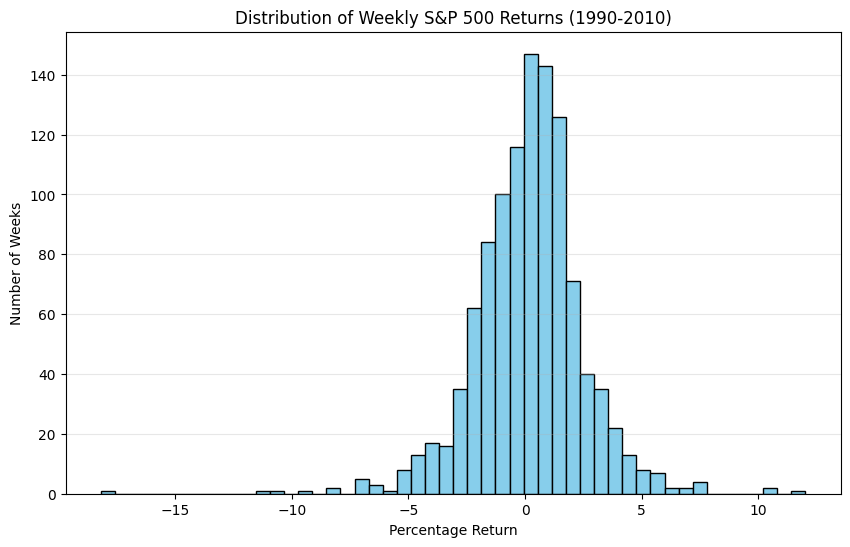

In [15]:
# Code for visualization 1
import matplotlib.pyplot as plt

# Create a histogram of the weekly returns
plt.figure(figsize=(10, 6))
plt.hist(Weekly['Today'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Weekly S&P 500 Returns (1990-2010)')
plt.xlabel('Percentage Return')
plt.ylabel('Number of Weeks')
plt.grid(axis='y', alpha=0.3)
plt.show()


This tries to show how often the market has big moves versus small ones.

### Visualization 2

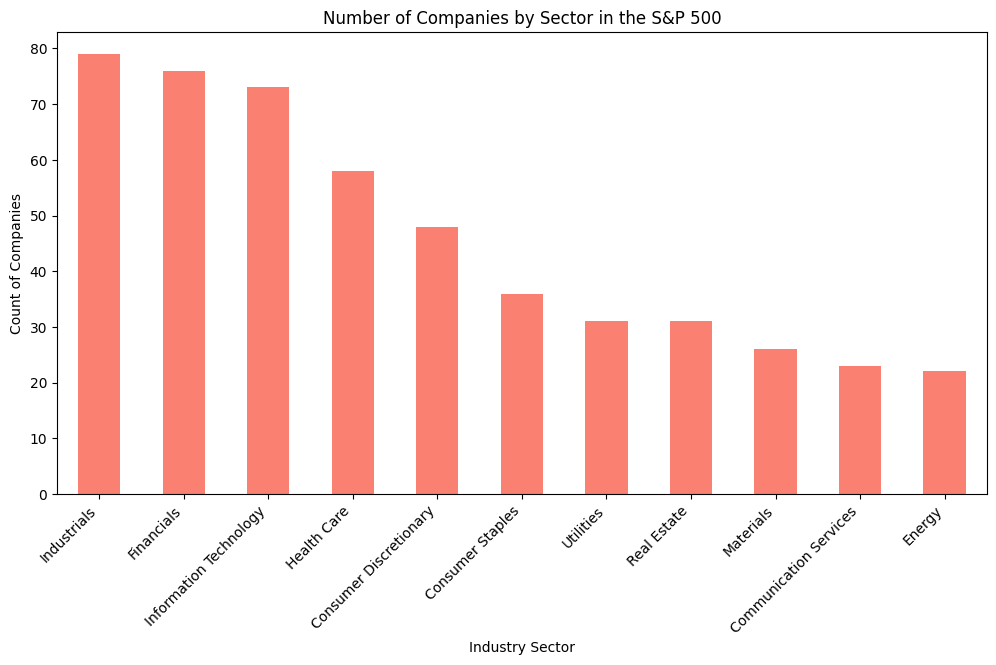

In [17]:
# Code for visualization
# Count how many companies are in each sector
sector_counts = sp500_df['gics_sector'].value_counts()

# Create a bar chart
plt.figure(figsize=(12, 6))
sector_counts.plot(kind='bar', color='salmon')
plt.title('Number of Companies by Sector in the S&P 500')
plt.xlabel('Industry Sector')
plt.ylabel('Count of Companies')
plt.xticks(rotation=45, ha='right')
plt.show()


This uses your Wikipedia data to show which industries dominate the S&P 500 on that period.

Visualization 3


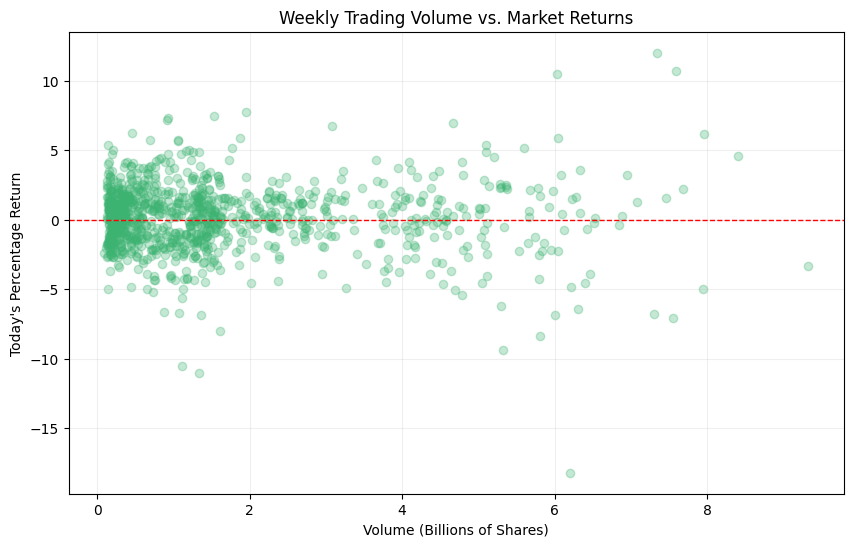

In [18]:
import matplotlib.pyplot as plt

# Create a scatter plot to see the relationship between Volume and Today's return
plt.figure(figsize=(10, 6))
plt.scatter(Weekly['Volume'], Weekly['Today'], alpha=0.3, color='mediumseagreen')
plt.title('Weekly Trading Volume vs. Market Returns')
plt.xlabel('Volume (Billions of Shares)')
plt.ylabel('Today\'s Percentage Return')
plt.axhline(0, color='red', linestyle='--', linewidth=1) # Adds a line at 0 for reference
plt.grid(True, alpha=0.2)
plt.show()

This scatter plot attempts to help us see if higher trading Volume leads to bigger market moves. The returns don't necessarily get higher or lower—they stay pretty balanced around the red zero line.

## Part 5: Executive Summary

This project explored a central question in stock analysis: Can we predict if the market goes "Up" or "Down" based on trading Volume? By combining 21 years of S&P 500 weekly data from the ISLP library with company sector information scraped from Wikipedia, I found that the relationship is far more complex than a simple "high volume equals high returns" rule.

My first visualization showed that while the market is usually stable, it’s prone to extreme volatility, such as the 18% weekly drop found in the historical records. During the study period, trading volume skyrocketed from under 1 billion to over 9 billion shares. However, my third visualization, the scatter plot, revealed that high volume doesn't actually predict direction. Instead, in my opinion it seems to act as a magnet for "outliers," meaning the biggest gains and losses happen when trading is most intense. My second chart showed the index is heavily weighted toward Information Technology and Industrials, which explains why nowadays tech news often triggers these massive volume spikes and subsequent market swings.

A major limitation of this study is the time frame, the data ends in 2010, so it misses the impact of modern high-frequency trading and AI-driven markets. Furthermore, the correlation between volume and price swings doesn't prove that volume causes the moves; it’s likely a reaction to external factors or economic news. For a next step, we would need to have way more data and cross reference building a complex model. This would allow us to mathematically test if "Lag" variables and Volume have any real statistical power to predict the market's direction or if the movements are truly just a random walk.



## Part 6: References

Wikipedia Data: List of S&P 500 companies. Accessed: April 28, 2026.

ISLP Dataset: Weekly dataset from the ISLP Python library. ISLP Documentation

Python Documentation: * Pandas read_html documentation

Matplotlib Pyplot tutorial